probleme :

Le seul dataset bien : cartpole_K1000_fixed que javais fix a la mano pour tester: 
- label_tau1_rate = 0.5037
- tie_rate = 0.0


Les trois premiers CartPole sont éclatés :
- cartpole_K50    -> label_tau1_rate = 0.98
- cartpole_K200   -> label_tau1_rate = 0.965
- cartpole_K500   -> label_tau1_rate = 0.958
acrobot_K50     label_tau1_rate = 0.82 \
acrobot_K200    label_tau1_rate = 0.82\
acrobot_K500    label_tau1_rate = 0.83\
acrobot_K1000   label_tau1_rate = 0.833


go faire ca pour tous !

In [1]:
import random
import pickle
import numpy as np
from pathlib import Path

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

def fix_preference_dataset(input_path, output_path):
    pairs = load_pickle(input_path)
    fixed_pairs = []

    n_ties = 0

    for pair in pairs:
        R1, R2, _ = get_R_label(pair)

        # Remove ties because preference is ambiguous
        if R1 == R2:
            n_ties += 1
            continue

        tau1 = pair["tau1"]
        tau2 = pair["tau2"]

        # Higher return is always better, even for Acrobot:
        # -100 is better than -300.
        if R1 > R2:
            preferred = tau1
            rejected = tau2
            preferred_return = R1
            rejected_return = R2
        else:
            preferred = tau2
            rejected = tau1
            preferred_return = R2
            rejected_return = R1

        # Randomize position to remove tau1 bias
        if random.random() < 0.5:
            new_pair = {
                "tau1": preferred,
                "tau2": rejected,
                "R1": preferred_return,
                "R2": rejected_return,
                "label": 1,
                "preferred": "tau1",
                "rejected": "tau2",
            }
        else:
            new_pair = {
                "tau1": rejected,
                "tau2": preferred,
                "R1": rejected_return,
                "R2": preferred_return,
                "label": 0,
                "preferred": "tau2",
                "rejected": "tau1",
            }

        fixed_pairs.append(new_pair)

    with open(output_path, "wb") as f:
        pickle.dump(fixed_pairs, f)

    return {
        "input": input_path.name,
        "output": output_path.name,
        "before": len(pairs),
        "after": len(fixed_pairs),
        "removed_ties": n_ties,
    }

In [3]:
from pathlib import Path

DATASET_DIR = Path("outputs/datasets")

DATASETS = {
    "cartpole_K50": DATASET_DIR / "cartpole_preferences_K50.pkl",
    "cartpole_K200": DATASET_DIR / "cartpole_preferences_K200.pkl",
    "cartpole_K500": DATASET_DIR / "cartpole_preferences_K500.pkl",
    "cartpole_K1000": DATASET_DIR / "cartpole_preferences_K1000_fixed.pkl",

    "acrobot_K50": DATASET_DIR / "acrobot_preferences_K50.pkl",
    "acrobot_K200": DATASET_DIR / "acrobot_preferences_K200.pkl",
    "acrobot_K500": DATASET_DIR / "acrobot_preferences_K500.pkl",
    "acrobot_K1000": DATASET_DIR / "acrobot_preferences_K1000.pkl",
}

for name, path in DATASETS.items():
    if path.exists():
        print("OK:", name, "->", path)
    else:
        print("MISSING:", name, "->", path)

OK: cartpole_K50 -> outputs/datasets/cartpole_preferences_K50.pkl
OK: cartpole_K200 -> outputs/datasets/cartpole_preferences_K200.pkl
OK: cartpole_K500 -> outputs/datasets/cartpole_preferences_K500.pkl
OK: cartpole_K1000 -> outputs/datasets/cartpole_preferences_K1000_fixed.pkl
OK: acrobot_K50 -> outputs/datasets/acrobot_preferences_K50.pkl
OK: acrobot_K200 -> outputs/datasets/acrobot_preferences_K200.pkl
OK: acrobot_K500 -> outputs/datasets/acrobot_preferences_K500.pkl
OK: acrobot_K1000 -> outputs/datasets/acrobot_preferences_K1000.pkl


In [5]:
import pickle
import numpy as np
import pandas as pd
from pathlib import Path

def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

def save_pickle(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(obj, f)

In [7]:
def get_R_label(pair):
    R1 = float(pair.get("R1", pair.get("tau1", {}).get("total_reward", np.nan)))
    R2 = float(pair.get("R2", pair.get("tau2", {}).get("total_reward", np.nan)))
    label = int(pair["label"])
    return R1, R2, label

In [8]:
FIXED_DATASETS = {}

fix_logs = []

for dataset_name, dataset_path in DATASETS.items():
    output_name = dataset_path.stem.replace("_fixed", "") + "_fixed.pkl"
    output_path = DATASET_DIR / output_name

    log = fix_preference_dataset(dataset_path, output_path)
    fix_logs.append(log)

    fixed_name = dataset_name.replace("_fixed", "") + "_fixed"
    FIXED_DATASETS[fixed_name] = output_path

fix_logs_df = pd.DataFrame(fix_logs)
display(fix_logs_df)

,input,output,before,after,removed_ties
0,cartpole_preferences_K50.pkl,cartpole_preferences_K50_fixed.pkl,50,47,3
1,cartpole_preferences_K200.pkl,cartpole_preferences_K200_fixed.pkl,200,187,13
2,cartpole_preferences_K500.pkl,cartpole_preferences_K500_fixed.pkl,500,466,34
3,cartpole_preferences_K1000_fixed.pkl,cartpole_preferences_K1000_fixed.pkl,935,935,0
4,acrobot_preferences_K50.pkl,acrobot_preferences_K50_fixed.pkl,50,50,0
5,acrobot_preferences_K200.pkl,acrobot_preferences_K200_fixed.pkl,200,197,3
6,acrobot_preferences_K500.pkl,acrobot_preferences_K500_fixed.pkl,500,494,6
7,acrobot_preferences_K1000.pkl,acrobot_preferences_K1000_fixed.pkl,1000,987,13


On supprime les paires où les deux trajectoires ont le même retour, car elles ne donnent pas de préférence claire.

on échange aléatoirement l’ordre des deux trajectoires en mettant à jour le label. Cela ne change pas la préférence réelle, mais évite que le modèle apprenne un biais de position, par exemple “tau1 gagne presque toujours”

avant :\
pair 1: tau1=500, tau2=100, label=1\
pair 2: tau1=450, tau2=120, label=1\
pair 3: tau1=480, tau2=80,  label=1\
pair 4: tau1=500, tau2=200, label=1

Après fix :\
pair 1: tau1=500, tau2=100, label=1\
pair 2: tau1=120, tau2=450, label=0\
pair 3: tau1=480, tau2=80,  label=1\
pair 4: tau1=200, tau2=500, label=0

on va voir avec un plot

In [10]:
def dataset_report(pairs):
    R1, R2, y = [], [], []

    for pair in pairs:
        r1, r2, label = get_R_label(pair)
        R1.append(r1)
        R2.append(r2)
        y.append(label)

    R1 = np.array(R1)
    R2 = np.array(R2)
    y = np.array(y)

    return {
        "n_pairs": len(pairs),
        "mean_R1": R1.mean(),
        "mean_R2": R2.mean(),
        "std_R1": R1.std(),
        "std_R2": R2.std(),
        "label_tau1_rate": y.mean(),
        "tie_rate": np.mean(R1 == R2),
        "mean_abs_return_diff": np.mean(np.abs(R1 - R2)),
        "median_abs_return_diff": np.median(np.abs(R1 - R2)),
    }

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

before_after = []

for dataset_name, dataset_path in DATASETS.items():
    original_pairs = load_pickle(dataset_path)
    original_report = dataset_report(original_pairs)

    fixed_name = dataset_name.replace("_fixed", "") + "_fixed"
    fixed_path = DATASET_DIR / (dataset_path.stem.replace("_fixed", "") + "_fixed.pkl")

    fixed_pairs = load_pickle(fixed_path)
    fixed_report = dataset_report(fixed_pairs)

    before_after.append({
        "dataset": dataset_name,
        "version": "before",
        "label_tau1_rate": original_report["label_tau1_rate"],
        "tie_rate": original_report["tie_rate"],
        "n_pairs": original_report["n_pairs"],
    })

    before_after.append({
        "dataset": dataset_name,
        "version": "after",
        "label_tau1_rate": fixed_report["label_tau1_rate"],
        "tie_rate": fixed_report["tie_rate"],
        "n_pairs": fixed_report["n_pairs"],
    })

before_after_df = pd.DataFrame(before_after)
display(before_after_df)

,dataset,version,label_tau1_rate,tie_rate,n_pairs
0,cartpole_K50,before,0.980000,0.060,50
1,cartpole_K50,after,0.489362,0.000,47
2,cartpole_K200,before,0.965000,0.065,200
3,cartpole_K200,after,0.508021,0.000,187
4,cartpole_K500,before,0.958000,0.068,500
5,cartpole_K500,after,0.493562,0.000,466
6,cartpole_K1000,before,0.475936,0.000,935
7,cartpole_K1000,after,0.475936,0.000,935
8,acrobot_K50,before,0.820000,0.000,50
9,acrobot_K50,after,0.560000,0.000,50


all good on passe a la suite : \
entraîner les reward models sur tous les datasets fixed


je re import tout comme ca cest indep, si on veut le mettre ailleurs

In [12]:
from pathlib import Path
import pickle, random, math, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

DATASET_DIR = Path("outputs/datasets")
REWARD_MODEL_DIR = Path("outputs/reward_models")
REPORT_DIR = Path("outputs/reports")

REWARD_MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

FIXED_DATASETS = {
    "cartpole_K50": DATASET_DIR / "cartpole_preferences_K50_fixed.pkl",
    "cartpole_K200": DATASET_DIR / "cartpole_preferences_K200_fixed.pkl",
    "cartpole_K500": DATASET_DIR / "cartpole_preferences_K500_fixed.pkl",
    "cartpole_K1000": DATASET_DIR / "cartpole_preferences_K1000_fixed.pkl",

    "acrobot_K50": DATASET_DIR / "acrobot_preferences_K50_fixed.pkl",
    "acrobot_K200": DATASET_DIR / "acrobot_preferences_K200_fixed.pkl",
    "acrobot_K500": DATASET_DIR / "acrobot_preferences_K500_fixed.pkl",
    "acrobot_K1000": DATASET_DIR / "acrobot_preferences_K1000_fixed.pkl",
}

for name, path in FIXED_DATASETS.items():
    print(name, "OK" if path.exists() else "MISSING", path)

device: cuda
GPU: Tesla V100-PCIE-32GB
cartpole_K50 OK outputs/datasets/cartpole_preferences_K50_fixed.pkl
cartpole_K200 OK outputs/datasets/cartpole_preferences_K200_fixed.pkl
cartpole_K500 OK outputs/datasets/cartpole_preferences_K500_fixed.pkl
cartpole_K1000 OK outputs/datasets/cartpole_preferences_K1000_fixed.pkl
acrobot_K50 OK outputs/datasets/acrobot_preferences_K50_fixed.pkl
acrobot_K200 OK outputs/datasets/acrobot_preferences_K200_fixed.pkl
acrobot_K500 OK outputs/datasets/acrobot_preferences_K500_fixed.pkl
acrobot_K1000 OK outputs/datasets/acrobot_preferences_K1000_fixed.pkl


In [13]:
def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

class PreferenceDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        pair = self.pairs[idx]

        s1 = torch.tensor(pair["tau1"]["states"], dtype=torch.float32)
        a1 = torch.tensor(pair["tau1"]["actions"], dtype=torch.long)

        s2 = torch.tensor(pair["tau2"]["states"], dtype=torch.float32)
        a2 = torch.tensor(pair["tau2"]["actions"], dtype=torch.long)

        label = torch.tensor(pair["label"], dtype=torch.float32)

        return s1, a1, s2, a2, label

def collate_fn(batch):
    s1, a1, s2, a2, y = zip(*batch)
    return list(s1), list(a1), list(s2), list(a2), torch.stack(y)

In [14]:
class RewardModel(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(state_dim + action_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

        self.action_dim = action_dim

    def forward_step(self, states, actions):
        actions_onehot = torch.nn.functional.one_hot(
            actions, num_classes=self.action_dim
        ).float()

        x = torch.cat([states, actions_onehot], dim=-1)
        rewards = self.net(x).squeeze(-1)
        return rewards

    def trajectory_return(self, states, actions):
        rewards = self.forward_step(states, actions)
        return rewards.sum()

In [15]:
def preference_loss(model, s1_list, a1_list, s2_list, a2_list, labels):
    logits = []

    for s1, a1, s2, a2 in zip(s1_list, a1_list, s2_list, a2_list):
        s1 = s1.to(device)
        a1 = a1.to(device)
        s2 = s2.to(device)
        a2 = a2.to(device)

        R1_hat = model.trajectory_return(s1, a1)
        R2_hat = model.trajectory_return(s2, a2)

        logits.append(R1_hat - R2_hat)

    logits = torch.stack(logits)
    labels = labels.to(device)

    loss = nn.functional.binary_cross_entropy_with_logits(logits, labels)

    preds = (torch.sigmoid(logits) >= 0.5).float()
    acc = (preds == labels).float().mean()

    return loss, acc


def train_one_reward_model(dataset_name, dataset_path, epochs=50, batch_size=32, lr=1e-3):
    print("\n==============================")
    print("Training:", dataset_name)
    print("==============================")

    pairs = load_pickle(dataset_path)

    first = pairs[0]
    state_dim = first["tau1"]["states"].shape[1]
    max_action = max(
        int(np.max(first["tau1"]["actions"])),
        int(np.max(first["tau2"]["actions"]))
    )
    action_dim = max_action + 1

    dataset = PreferenceDataset(pairs)

    n_train = int(0.8 * len(dataset))
    n_val = len(dataset) - n_train

    train_set, val_set = random_split(
        dataset,
        [n_train, n_val],
        generator=torch.Generator().manual_seed(SEED)
    )

    train_loader = DataLoader(
        train_set,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_fn
    )

    val_loader = DataLoader(
        val_set,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn
    )

    model = RewardModel(state_dim=state_dim, action_dim=action_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        train_accs = []

        for s1, a1, s2, a2, y in train_loader:
            optimizer.zero_grad()
            loss, acc = preference_loss(model, s1, a1, s2, a2, y)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())
            train_accs.append(acc.item())

        model.eval()
        val_losses = []
        val_accs = []

        with torch.no_grad():
            for s1, a1, s2, a2, y in val_loader:
                loss, acc = preference_loss(model, s1, a1, s2, a2, y)
                val_losses.append(loss.item())
                val_accs.append(acc.item())

        row = {
            "dataset": dataset_name,
            "epoch": epoch,
            "train_loss": np.mean(train_losses),
            "train_acc": np.mean(train_accs),
            "val_loss": np.mean(val_losses),
            "val_acc": np.mean(val_accs),
            "n_pairs": len(dataset),
        }

        history.append(row)

        if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
            print(
                f"epoch {epoch:03d} | "
                f"train loss {row['train_loss']:.3f} | "
                f"train acc {row['train_acc']:.3f} | "
                f"val loss {row['val_loss']:.3f} | "
                f"val acc {row['val_acc']:.3f}"
            )

    model_path = REWARD_MODEL_DIR / f"reward_model_{dataset_name}.pt"
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "state_dim": state_dim,
            "action_dim": action_dim,
            "dataset": dataset_name,
        },
        model_path,
    )

    print("saved:", model_path)

    return model, pd.DataFrame(history)

In [16]:
all_histories = []

for dataset_name, dataset_path in FIXED_DATASETS.items():
    model, hist = train_one_reward_model(
        dataset_name=dataset_name,
        dataset_path=dataset_path,
        epochs=50,
        batch_size=32,
        lr=1e-3,
    )

    all_histories.append(hist)

history_df = pd.concat(all_histories, ignore_index=True)
display(history_df.tail())

history_df.to_csv(REPORT_DIR / "reward_model_training_history.csv", index=False)


Training: cartpole_K50
epoch 001 | train loss 28.502 | train acc 0.200 | val loss 0.012 | val acc 1.000
epoch 010 | train loss 0.000 | train acc 1.000 | val loss 0.000 | val acc 1.000
epoch 020 | train loss 0.000 | train acc 1.000 | val loss 0.000 | val acc 1.000
epoch 030 | train loss 0.000 | train acc 1.000 | val loss 0.000 | val acc 1.000
epoch 040 | train loss 0.000 | train acc 1.000 | val loss 0.000 | val acc 1.000
epoch 050 | train loss 0.000 | train acc 1.000 | val loss 0.000 | val acc 1.000
saved: outputs/reward_models/reward_model_cartpole_K50.pt

Training: cartpole_K200
epoch 001 | train loss 0.250 | train acc 0.984 | val loss 0.000 | val acc 1.000
epoch 010 | train loss 0.014 | train acc 0.988 | val loss 0.000 | val acc 1.000
epoch 020 | train loss 0.000 | train acc 1.000 | val loss 0.000 | val acc 1.000
epoch 030 | train loss 0.000 | train acc 1.000 | val loss 0.000 | val acc 1.000
epoch 040 | train loss 0.000 | train acc 1.000 | val loss 0.000 | val acc 1.000
epoch 050 | 

,dataset,epoch,train_loss,train_acc,val_loss,val_acc,n_pairs
395,acrobot_K1000,46,0.003780,0.99875,0.059689,0.986607,987
396,acrobot_K1000,47,0.003044,1.00000,0.055146,0.986607,987
397,acrobot_K1000,48,0.002986,1.00000,0.063655,0.986607,987
398,acrobot_K1000,49,0.003189,0.99875,0.047346,0.986607,987
399,acrobot_K1000,50,0.002557,1.00000,0.059377,0.986607,987


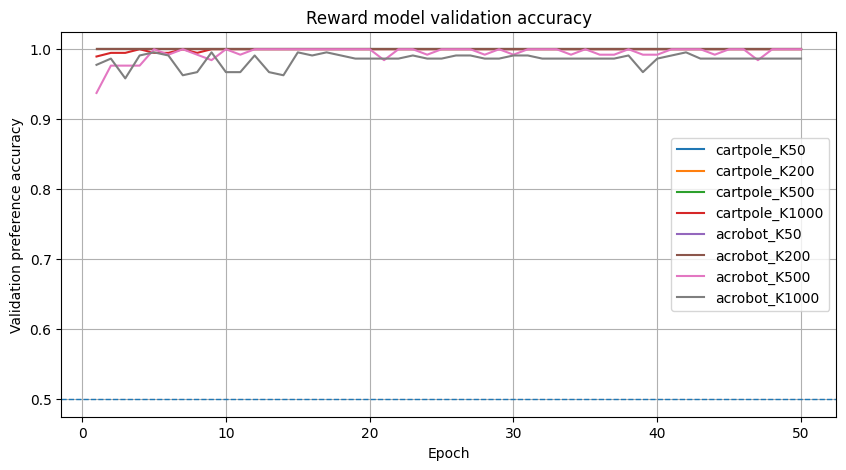

In [17]:
plt.figure(figsize=(10, 5))

for dataset_name in history_df["dataset"].unique():
    sub = history_df[history_df["dataset"] == dataset_name]
    plt.plot(sub["epoch"], sub["val_acc"], label=dataset_name)

plt.axhline(0.5, linestyle="--", linewidth=1)
plt.xlabel("Epoch")
plt.ylabel("Validation preference accuracy")
plt.title("Reward model validation accuracy")
plt.legend()
plt.grid(True)
plt.show()

le résultat est trop parfait...


on va tester si le reward model prédit un score qui est corrélé avec le vrai return.

In [20]:
from scipy.stats import pearsonr, spearmanr

def predicted_return(model, tau):
    model.eval()
    states = torch.tensor(tau["states"], dtype=torch.float32).to(device)
    actions = torch.tensor(tau["actions"], dtype=torch.long).to(device)

    with torch.no_grad():
        pred = model.trajectory_return(states, actions).item()

    return pred


def evaluate_reward_model_correlation(dataset_name, dataset_path):
    pairs = load_pickle(dataset_path)

    checkpoint = torch.load(
        REWARD_MODEL_DIR / f"reward_model_{dataset_name}.pt",
        map_location=device
    )

    model = RewardModel(
        state_dim=checkpoint["state_dim"],
        action_dim=checkpoint["action_dim"]
    ).to(device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    true_returns = []
    pred_returns = []

    for pair in pairs:
        for tau_name in ["tau1", "tau2"]:
            tau = pair[tau_name]

            true_R = float(tau.get("total_reward", np.nan))
            pred_R = predicted_return(model, tau)

            true_returns.append(true_R)
            pred_returns.append(pred_R)

    true_returns = np.array(true_returns)
    pred_returns = np.array(pred_returns)

    pearson = pearsonr(true_returns, pred_returns).statistic
    spearman = spearmanr(true_returns, pred_returns).statistic

    return {
        "dataset": dataset_name,
        "pearson": pearson,
        "spearman": spearman,
        "true_returns": true_returns,
        "pred_returns": pred_returns,
    }


correlation_results = []

for dataset_name, dataset_path in FIXED_DATASETS.items():
    res = evaluate_reward_model_correlation(dataset_name, dataset_path)
    correlation_results.append(res)

corr_df = pd.DataFrame([
    {
        "dataset": r["dataset"],
        "pearson": r["pearson"],
        "spearman": r["spearman"],
    }
    for r in correlation_results
])

display(corr_df)
corr_df.to_csv(REPORT_DIR / "reward_model_return_correlation.csv", index=False)

,dataset,pearson,spearman
0,cartpole_K50,0.989309,0.935097
1,cartpole_K200,0.991227,0.935671
2,cartpole_K500,0.997969,0.944371
3,cartpole_K1000,0.995805,0.946651
4,acrobot_K50,0.982310,0.983407
5,acrobot_K200,0.998401,0.994708
6,acrobot_K500,0.999010,0.996154
7,acrobot_K1000,0.999267,0.995487


le reward model prédit un score qui est très fortement aligné avec le vrai return environnemental. \ 
Le dataset de préférences est assez simple/séparable.

mtn faut entraîner une policy avec le reward model au lieu du vrai reward Gym.

In [21]:
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import gymnasium as gym

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.evaluation import evaluate_policy

In [22]:
BASE = Path("outputs")
REWARD_MODEL_DIR = BASE / "reward_models"
POLICY_DIR = BASE / "policies_learned_reward"
POLICY_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

device: cuda
Tesla V100-PCIE-32GB


In [25]:
class RewardModel(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim + act_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, obs, act):
        x = torch.cat([obs, act], dim=-1)
        return self.net(x).squeeze(-1)

In [26]:
class LearnedRewardWrapper(gym.Wrapper):
    def __init__(self, env, reward_model, obs_dim, act_dim, device):
        super().__init__(env)
        self.reward_model = reward_model
        self.obs_dim = obs_dim
        self.act_dim = act_dim
        self.device = device

    def step(self, action):
        obs, true_reward, terminated, truncated, info = self.env.step(action)

        obs_tensor = torch.tensor(obs, dtype=torch.float32, device=self.device).unsqueeze(0)

        action_onehot = np.zeros(self.act_dim, dtype=np.float32)
        action_onehot[int(action)] = 1.0
        action_tensor = torch.tensor(action_onehot, dtype=torch.float32, device=self.device).unsqueeze(0)

        with torch.no_grad():
            learned_reward = self.reward_model(obs_tensor, action_tensor).item()

        info["true_reward"] = true_reward
        info["learned_reward"] = learned_reward

        return obs, learned_reward, terminated, truncated, info

In [27]:
env_id = "CartPole-v1"
dataset_name = "cartpole_K1000"

tmp_env = gym.make(env_id)
obs_dim = tmp_env.observation_space.shape[0]
act_dim = tmp_env.action_space.n
tmp_env.close()

reward_model = RewardModel(obs_dim=obs_dim, act_dim=act_dim).to(device)

ckpt_path = REWARD_MODEL_DIR / "reward_model_cartpole_K1000.pt"
ckpt = torch.load(ckpt_path, map_location=device)

if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
    reward_model.load_state_dict(ckpt["model_state_dict"])
else:
    reward_model.load_state_dict(ckpt)

reward_model.eval()

print("loaded:", ckpt_path)

loaded: outputs/reward_models/reward_model_cartpole_K1000.pt


In [28]:
def make_learned_reward_env():
    env = gym.make(env_id)
    env = LearnedRewardWrapper(env, reward_model, obs_dim, act_dim, device)
    env = Monitor(env)
    return env

vec_env = DummyVecEnv([make_learned_reward_env])

In [29]:
model = PPO(
    "MlpPolicy",
    vec_env,
    verbose=1,
    device=device,
    learning_rate=3e-4,
    n_steps=1024,
    batch_size=64,
    gamma=0.99,
    seed=42,
)

model.learn(total_timesteps=50_000)

save_path = POLICY_DIR / "ppo_cartpole_K1000_learned_reward"
model.save(save_path)

print("saved:", save_path)

Using cuda device


/home/misenta/miniconda3/envs/rl-v100/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 24.2     |
|    ep_rew_mean     | 12.7     |
| time/              |          |
|    fps             | 222      |
|    iterations      | 1        |
|    time_elapsed    | 4        |
|    total_timesteps | 1024     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 26.1        |
|    ep_rew_mean          | 13.9        |
| time/                   |             |
|    fps                  | 263         |
|    iterations           | 2           |
|    time_elapsed         | 7           |
|    total_timesteps      | 2048        |
| train/                  |             |
|    approx_kl            | 0.008174317 |
|    clip_fraction        | 0.0864      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.687      |
|    explained_variance   | -0.0262     |
|    learning_rate        | 0.

In [30]:
true_eval_env = gym.make(env_id)
true_eval_env = Monitor(true_eval_env)

mean_return, std_return = evaluate_policy(
    model,
    true_eval_env,
    n_eval_episodes=20,
    deterministic=True,
)

true_eval_env.close()

print("True environment return:")
print("mean:", mean_return)
print("std:", std_return)

True environment return:
mean: 500.0
std: 0.0


In [31]:
def make_true_env():
    return Monitor(gym.make(env_id))

true_vec_env = DummyVecEnv([make_true_env])

true_reward_model = PPO(
    "MlpPolicy",
    true_vec_env,
    verbose=1,
    device=device,
    learning_rate=3e-4,
    n_steps=1024,
    batch_size=64,
    gamma=0.99,
    seed=42,
)

true_reward_model.learn(total_timesteps=50_000)

mean_true, std_true = evaluate_policy(
    true_reward_model,
    Monitor(gym.make(env_id)),
    n_eval_episodes=20,
    deterministic=True,
)

print("PPO trained with true reward:")
print("mean:", mean_true)
print("std:", std_true)

Using cuda device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 24.2     |
|    ep_rew_mean     | 24.2     |
| time/              |          |
|    fps             | 1115     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 1024     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 25.6        |
|    ep_rew_mean          | 25.6        |
| time/                   |             |
|    fps                  | 858         |
|    iterations           | 2           |
|    time_elapsed         | 2           |
|    total_timesteps      | 2048        |
| train/                  |             |
|    approx_kl            | 0.007981237 |
|    clip_fraction        | 0.0941      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.687      |
|    explained_variance   | -0.00408    |
|    learnin

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def evaluate_policy_detailed(model, env_id, n_eval_episodes=20, max_steps=500, render=False):
    env = gym.make(env_id)

    episode_returns = []
    episode_lengths = []

    for ep in range(n_eval_episodes):
        obs, info = env.reset(seed=SEED + ep)
        done = False
        truncated = False

        total_reward = 0.0
        length = 0

        while not (done or truncated) and length < max_steps:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, truncated, info = env.step(action)

            total_reward += reward
            length += 1

        episode_returns.append(total_reward)
        episode_lengths.append(length)

    env.close()

    df = pd.DataFrame({
        "episode": np.arange(n_eval_episodes),
        "return": episode_returns,
        "length": episode_lengths,
    })

    print("===== Evaluation details =====")
    print("env:", env_id)
    print("n episodes:", n_eval_episodes)
    print()
    print("Returns:")
    print("mean  :", df["return"].mean())
    print("std   :", df["return"].std())
    print("min   :", df["return"].min())
    print("25%   :", df["return"].quantile(0.25))
    print("median:", df["return"].median())
    print("75%   :", df["return"].quantile(0.75))
    print("max   :", df["return"].max())
    print()
    print("Lengths:")
    print("mean  :", df["length"].mean())
    print("std   :", df["length"].std())
    print("min   :", df["length"].min())
    print("max   :", df["length"].max())
    print()
    print(df)

    return df

In [38]:
df_eval = evaluate_policy_detailed(
    model=model,
    env_id="CartPole-v1",
    n_eval_episodes=30,
    max_steps=500
)

===== Evaluation details =====
env: CartPole-v1
n episodes: 30

Returns:
mean  : 500.0
std   : 0.0
min   : 500.0
25%   : 500.0
median: 500.0
75%   : 500.0
max   : 500.0

Lengths:
mean  : 500.0
std   : 0.0
min   : 500
max   : 500

    episode  return  length
0         0   500.0     500
1         1   500.0     500
2         2   500.0     500
3         3   500.0     500
4         4   500.0     500
5         5   500.0     500
6         6   500.0     500
7         7   500.0     500
8         8   500.0     500
9         9   500.0     500
10       10   500.0     500
11       11   500.0     500
12       12   500.0     500
13       13   500.0     500
14       14   500.0     500
15       15   500.0     500
16       16   500.0     500
17       17   500.0     500
18       18   500.0     500
19       19   500.0     500
20       20   500.0     500
21       21   500.0     500
22       22   500.0     500
23       23   500.0     500
24       24   500.0     500
25       25   500.0     500
26       26   

CartPole est un environnement trop facile je pense. Le score max est 500, donc le PPO avec la vraie reward a appris une policy parfaite :\
return = 500\
length = 500\
std = 0

la meme pour acrobot MAIS JAI PAS LE TIIIMMME

In [ ]:
results = []

for dataset_name in [
    "cartpole_K50",
    "cartpole_K200",
    "cartpole_K500",
    "cartpole_K1000",
]:
    print("\n==============================")
    print("Training PPO with learned reward:", dataset_name)
    print("==============================")

    reward_model_path = REWARD_MODEL_DIR / f"reward_model_{dataset_name}.pt"

    ppo_rm = train_ppo_with_learned_reward(
        env_id="CartPole-v1",
        reward_model_path=reward_model_path,
        total_timesteps=50_000,
    )

    df_eval = evaluate_policy_detailed(
        model=ppo_rm,
        env_id="CartPole-v1",
        n_eval_episodes=30,
        max_steps=500,
    )

    results.append({
        "dataset": dataset_name,
        "mean_return": df_eval["return"].mean(),
        "std_return": df_eval["return"].std(),
        "min_return": df_eval["return"].min(),
        "max_return": df_eval["return"].max(),
        "mean_length": df_eval["length"].mean(),
    })

results_df = pd.DataFrame(results)
display(results_df)

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(results_df["dataset"], results_df["mean_return"])
plt.axhline(500, linestyle="--", label="max CartPole score")
plt.xticks(rotation=45)
plt.ylabel("True environment return")
plt.title("PPO trained with learned reward models on CartPole")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
for dataset_name in [
    "acrobot_K50",
    "acrobot_K200",
    "acrobot_K500",
    "acrobot_K1000",
]:
    ...